<a href="https://colab.research.google.com/github/setdaygamer12/Project-Ai-du-doan-chi-tay/blob/APP-d%E1%BB%B1-%C4%91o%C3%A1n-ch%E1%BB%89-tay/Palmistry_Train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image, ImageEnhance, ImageFilter
from google.colab import files

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

print("✅ Import thư viện xong!")
print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

✅ Import thư viện xong!
TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
BASE_DIR = '/content/drive/MyDrive/Palmistry AI'
OUTPUT_DIR = BASE_DIR
MODEL_PATH = os.path.join(OUTPUT_DIR, 'Palmistry Ai.h5')
CLASS_PATH = os.path.join(OUTPUT_DIR, 'class_indices.json')
DANH_SACH_DUONG = [
    'Sinh_Dao',
    'Su_Nghiep',
    'Tam_Dao',
    'Tri_Dao'
]
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
print("📁 Thư mục dữ liệu:", BASE_DIR)
print("📁 Thư mục lưu model:", OUTPUT_DIR)
print("📌 Model sẽ lưu tại:", MODEL_PATH)
print("📌 Class file sẽ lưu tại:", CLASS_PATH)
print("📌 Danh sách class:", DANH_SACH_DUONG)

📁 Thư mục dữ liệu: /content/drive/MyDrive/Palmistry AI
📁 Thư mục lưu model: /content/drive/MyDrive/Palmistry AI
📌 Model sẽ lưu tại: /content/drive/MyDrive/Palmistry AI/Palmistry Ai.h5
📌 Class file sẽ lưu tại: /content/drive/MyDrive/Palmistry AI/class_indices.json
📌 Danh sách class: ['Sinh_Dao', 'Su_Nghiep', 'Tam_Dao', 'Tri_Dao']


In [ ]:
tong_anh = 0

print("Kiểm tra số lượng ảnh trong từng class:\n")

for ten_duong in DANH_SACH_DUONG:
    folder_path = os.path.join(BASE_DIR, ten_duong)

    if not os.path.exists(folder_path):
        print(f"❌ Không tìm thấy thư mục: {ten_duong}")
        continue

    dem = 0

    for file_name in os.listdir(folder_path):
        if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            dem += 1

    tong_anh += dem
    print(f"✅ {ten_duong}: {dem} ảnh")

print("\nTổng số ảnh:", tong_anh)

✅ Sinh_Dao: 168 ảnh
✅ Su_Nghiep: 168 ảnh
✅ Tam_Dao: 168 ảnh
✅ Tri_Dao: 168 ảnh

Tổng số ảnh: 672


In [ ]:
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=DANH_SACH_DUONG,
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=DANH_SACH_DUONG,
    subset='validation',
    shuffle=False
)

print("✅ Đã tạo dữ liệu train và validation!")
print("Class indices:", train_data.class_indices)

Found 540 images belonging to 4 classes.
Found 132 images belonging to 4 classes.
✅ Đã tạo dữ liệu train và validation!
Class indices: {'Sinh_Dao': 0, 'Su_Nghiep': 1, 'Tam_Dao': 2, 'Tri_Dao': 3}


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Đã tạo model Transfer Learning!")
model.summary()

✅ Đã tạo model Transfer Learning!


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
print("Bắt đầu huấn luyện model...")

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=40
)

print("Huấn luyện hoàn tất!")

Bắt đầu huấn luyện model...
Epoch 1/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.4204 - loss: 1.3302 - val_accuracy: 0.7348 - val_loss: 0.8006
Epoch 2/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 662ms/step - accuracy: 0.7667 - loss: 0.6389 - val_accuracy: 0.8788 - val_loss: 0.5049
Epoch 3/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 669ms/step - accuracy: 0.8333 - loss: 0.4818 - val_accuracy: 0.8712 - val_loss: 0.3887
Epoch 4/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 769ms/step - accuracy: 0.8648 - loss: 0.3996 - val_accuracy: 0.8712 - val_loss: 0.3701
Epoch 5/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 803ms/step - accuracy: 0.9056 - loss: 0.3025 - val_accuracy: 0.8788 - val_loss: 0.3621
Epoch 6/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 593ms/step - accuracy: 0.9093 - loss: 0.2592 - val_accuracy: 0.9015 - val_loss: 0.2668
Epoch 7/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 617ms/step - accuracy: 0.9093 - loss: 0.2762 - val_accuracy: 0.9091 - val_loss: 0.3047
Epoch 8/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 655ms/step - accuracy: 0.9370 

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Bắt đầu fine-tuning model...")

history_finetune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

print("Fine-tuning hoàn tất!")

Bắt đầu fine-tuning model...
Epoch 1/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.9259 - loss: 0.1905 - val_accuracy: 0.9470 - val_loss: 0.1583
Epoch 2/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 681ms/step - accuracy: 0.9519 - loss: 0.1204 - val_accuracy: 0.9621 - val_loss: 0.1557
Epoch 3/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 631ms/step - accuracy: 0.9593 - loss: 0.1222 - val_accuracy: 0.9167 - val_loss: 0.2844
Epoch 4/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 672ms/step - accuracy: 0.9537 - loss: 0.1442 - val_accuracy: 0.9470 - val_loss: 0.1892
Epoch 5/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 665ms/step - accuracy: 0.9574 - loss: 0.1045 - val_accuracy: 0.9394 - val_loss: 0.2622
Epoch 6/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 640ms/step - accuracy: 0.9648 - loss: 0.0998 - val_accuracy: 0.9545 - val_loss: 0.1403
Epoch 7/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 559ms/step - accuracy: 0.9778 - loss: 0.0606 - val_accuracy: 0.9545 - val_loss: 0.1611
Epoch 8/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 659ms/step - accuracy: 0.9704

In [ ]:
import json
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
model.save(MODEL_PATH)
with open(CLASS_PATH, 'w', encoding='utf-8') as f:
    json.dump(train_data.class_indices, f, ensure_ascii=False, indent=4)

print("✅ Đã lưu model tại:")
print(MODEL_PATH)

print("\n✅ Đã lưu class indices tại:")
print(CLASS_PATH)

print("\nClass indices:")
print(train_data.class_indices)

✅ Đã lưu model tại:
/content/drive/MyDrive/Palmistry AI/Palmistry Ai.h5

✅ Đã lưu class indices tại:
/content/drive/MyDrive/Palmistry AI/class_indices.json

Class indices:
{'Sinh_Dao': 0, 'Su_Nghiep': 1, 'Tam_Dao': 2, 'Tri_Dao': 3}


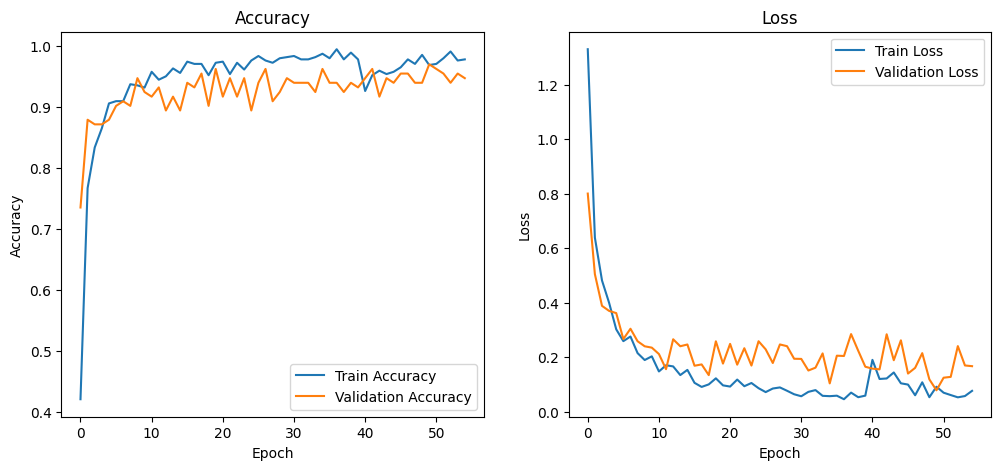

Accuracy cao nhất: 96.97 %


In [ ]:

acc = history.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history.history['val_accuracy'] + history_finetune.history['val_accuracy']

loss = history.history['loss'] + history_finetune.history['loss']
val_loss = history.history['val_loss'] + history_finetune.history['val_loss']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

print("Accuracy cao nhất:", round(max(val_acc) * 100, 2), "%")

In [ ]:
model_test = load_model(MODEL_PATH)

with open(CLASS_PATH, 'r', encoding='utf-8') as f:
    class_indices = json.load(f)

index_to_class = {v: k for k, v in class_indices.items()}

print("✅ Load model thành công!")
print("Class indices:", class_indices)
print("Index to class:", index_to_class)

✅ Load model thành công!
Class indices: {'Sinh_Dao': 0, 'Su_Nghiep': 1, 'Tam_Dao': 2, 'Tri_Dao': 3}
Index to class: {0: 'Sinh_Dao', 1: 'Su_Nghiep', 2: 'Tam_Dao', 3: 'Tri_Dao'}


✅ Cấu hình xong.
✅ Tìm thấy ảnh test: /content/2ead868d-7d42-4313-b19d-949b98284d46.jpg
✅ Import MediaPipe thành công.
✅ Khởi tạo MediaPipe Hand Landmarker thành công!


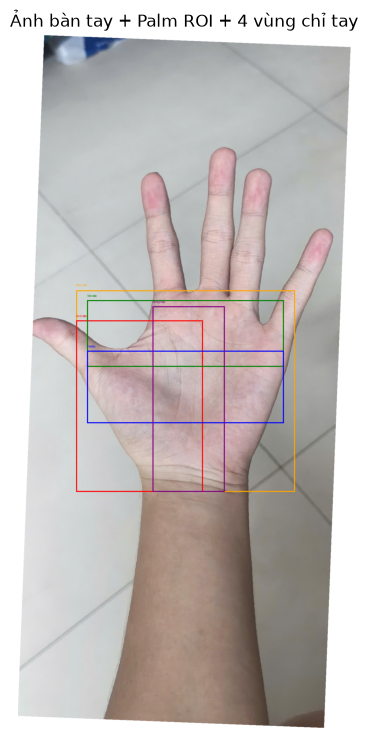

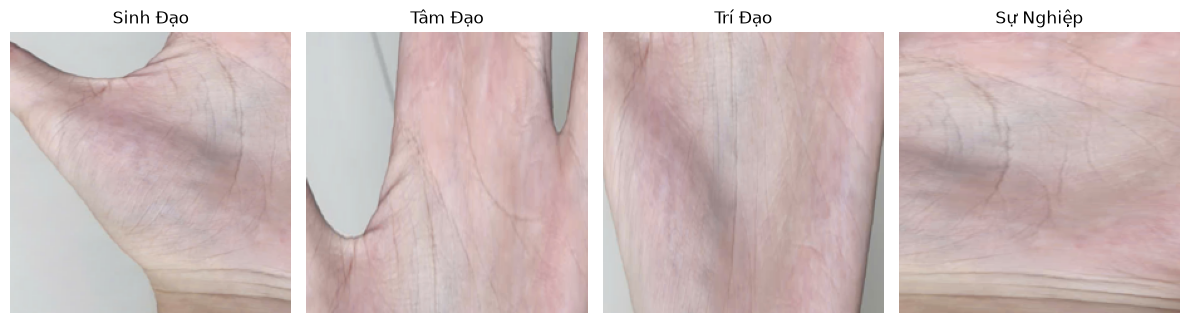

✅ MediaPipe crop 4 vùng thành công!
Các vùng đã crop: ['Sinh_Dao', 'Tam_Dao', 'Tri_Dao', 'Su_Nghiep']


In [ ]:
import os
import math
import urllib.request
import shutil
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw
from google.colab import files

TEST_IMAGE_PATH = "/content/2ead868d-7d42-4313-b19d-949b98284d46.jpg"

IMG_SIZE = (224, 224)

THU_TU_VUNG = [
    "Sinh_Dao",
    "Tam_Dao",
    "Tri_Dao",
    "Su_Nghiep"
]

TEN_HIEN_THI = {
    "Sinh_Dao": "Sinh Đạo",
    "Tam_Dao": "Tâm Đạo",
    "Tri_Dao": "Trí Đạo",
    "Su_Nghiep": "Sự Nghiệp"
}

print("✅ Cấu hình xong.")

if not os.path.exists(TEST_IMAGE_PATH):
    print("⚠️ Không thấy ảnh trong /content.")
    print("👉 Hãy upload ảnh bàn tay gốc.")

    uploaded = files.upload()

    if len(uploaded) > 0:
        ten_file = list(uploaded.keys())[0]
        shutil.copy(ten_file, TEST_IMAGE_PATH)
        print("✅ Đã lưu ảnh test thành:", TEST_IMAGE_PATH)
    else:
        print("❌ Chưa upload ảnh.")
else:
    print("✅ Tìm thấy ảnh test:", TEST_IMAGE_PATH)

MP_OK = True

try:
    import mediapipe as mp
    from mediapipe.tasks import python
    from mediapipe.tasks.python import vision
    print("✅ Import MediaPipe thành công.")
except Exception as e:
    print("❌ MediaPipe vẫn lỗi:", e)
    print("👉 Bạn cần restart session sau khi cài lại MediaPipe.")
    MP_OK = False

detector = None

if MP_OK:
    HAND_MODEL_PATH = "/content/hand_landmarker.task"

    try:
        if not os.path.exists(HAND_MODEL_PATH):
            print("📥 Đang tải hand_landmarker.task...")
            url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
            urllib.request.urlretrieve(url, HAND_MODEL_PATH)
            print("✅ Tải xong hand_landmarker.task.")

        base_options = python.BaseOptions(model_asset_path=HAND_MODEL_PATH)

        options = vision.HandLandmarkerOptions(
            base_options=base_options,
            num_hands=1
        )

        detector = vision.HandLandmarker.create_from_options(options)

        print("✅ Khởi tạo MediaPipe Hand Landmarker thành công!")

    except Exception as e:
        print("❌ Lỗi khi tạo detector:", e)
        detector = None

def tim_diem_ban_tay(anh_pil):
    if detector is None:
        return None

    anh_rgb = anh_pil.convert("RGB")
    arr = np.array(anh_rgb)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=arr
    )

    result = detector.detect(mp_image)

    if not result.hand_landmarks:
        return None

    h, w, _ = arr.shape
    landmarks = result.hand_landmarks[0]

    diem = []

    for lm in landmarks:
        x = int(lm.x * w)
        y = int(lm.y * h)
        diem.append([x, y])

    return np.array(diem)

def xoay_tay_cho_thang(anh_pil):
    diem = tim_diem_ban_tay(anh_pil)

    if diem is None:
        print("❌ Không phát hiện được bàn tay.")
        return None, None

    wrist = diem[0]
    middle_mcp = diem[9]

    dx = middle_mcp[0] - wrist[0]
    dy = middle_mcp[1] - wrist[1]

    goc_hien_tai = math.degrees(math.atan2(dy, dx))
    goc_can_xoay = -90 - goc_hien_tai

    anh_xoay = anh_pil.rotate(
        goc_can_xoay,
        expand=True,
        fillcolor=(255, 255, 255)
    )

    diem_sau_xoay = tim_diem_ban_tay(anh_xoay)

    if diem_sau_xoay is None:
        print("⚠️ Sau khi xoay không detect được, dùng ảnh gốc.")
        return anh_pil, diem

    return anh_xoay, diem_sau_xoay

def gioi_han_box(x1, y1, x2, y2, w, h):
    x1 = max(0, min(int(x1), w - 1))
    y1 = max(0, min(int(y1), h - 1))
    x2 = max(1, min(int(x2), w))
    y2 = max(1, min(int(y2), h))

    if x2 <= x1:
        x2 = min(w, x1 + 1)

    if y2 <= y1:
        y2 = min(h, y1 + 1)

    return x1, y1, x2, y2

def tao_palm_box(anh_pil, diem):
    w, h = anh_pil.size

    wrist = diem[0]
    index_mcp = diem[5]
    middle_mcp = diem[9]
    ring_mcp = diem[13]
    pinky_mcp = diem[17]
    thumb_mcp = diem[2]

    palm_points = np.array([
        wrist,
        thumb_mcp,
        index_mcp,
        middle_mcp,
        ring_mcp,
        pinky_mcp
    ])

    x1 = np.min(palm_points[:, 0])
    x2 = np.max(palm_points[:, 0])

    y1 = np.min([
        index_mcp[1],
        middle_mcp[1],
        ring_mcp[1],
        pinky_mcp[1]
    ])

    y2 = wrist[1]

    if y2 < y1:
        y1, y2 = y2, y1

    bw = x2 - x1
    bh = y2 - y1

    x1 = x1 - 0.18 * bw
    x2 = x2 + 0.18 * bw
    y1 = y1 - 0.12 * bh
    y2 = y2 + 0.12 * bh

    return gioi_han_box(x1, y1, x2, y2, w, h)

def crop_roi_theo_palm_box(anh_pil, diem, palm_box, u1, u2, v1, v2):
    """
    u: chiều ngang lòng bàn tay, tính từ phía ngón cái sang phía ngón út
    v: chiều dọc, tính từ chân ngón tay xuống cổ tay
    """

    left, top, right, bottom = palm_box

    palm_w = right - left
    palm_h = bottom - top

    thumb_x = diem[2][0]
    pinky_x = diem[17][0]

    if thumb_x < pinky_x:
        x1 = left + u1 * palm_w
        x2 = left + u2 * palm_w
    else:
        x1 = right - u1 * palm_w
        x2 = right - u2 * palm_w

    y1 = top + v1 * palm_h
    y2 = top + v2 * palm_h

    w, h = anh_pil.size
    x1, y1, x2, y2 = gioi_han_box(x1, y1, x2, y2, w, h)

    crop = anh_pil.crop((x1, y1, x2, y2))
    crop = crop.resize(IMG_SIZE)

    return crop, (x1, y1, x2, y2)

def auto_crop_4_vung(duong_dan_anh):
    anh_goc = Image.open(duong_dan_anh).convert("RGB")

    anh_xoay, diem = xoay_tay_cho_thang(anh_goc)

    if diem is None:
        return None, None, None

    palm_box = tao_palm_box(anh_xoay, diem)

    crops = {}
    boxes = {}

    # Sinh Đạo: phía ngón cái, kéo xuống dưới
    crops["Sinh_Dao"], boxes["Sinh_Dao"] = crop_roi_theo_palm_box(
        anh_xoay, diem, palm_box,
        0.00, 0.58,
        0.15, 1.00
    )

    # Tâm Đạo: ngang phía trên lòng bàn tay
    crops["Tam_Dao"], boxes["Tam_Dao"] = crop_roi_theo_palm_box(
        anh_xoay, diem, palm_box,
        0.05, 0.95,
        0.05, 0.38
    )

    # Trí Đạo: ngang giữa lòng bàn tay
    crops["Tri_Dao"], boxes["Tri_Dao"] = crop_roi_theo_palm_box(
        anh_xoay, diem, palm_box,
        0.05, 0.95,
        0.30, 0.66
    )

    # Sự Nghiệp: dọc giữa lòng bàn tay
    crops["Su_Nghiep"], boxes["Su_Nghiep"] = crop_roi_theo_palm_box(
        anh_xoay, diem, palm_box,
        0.35, 0.68,
        0.08, 1.00
    )

    anh_minh_hoa = anh_xoay.copy()
    draw = ImageDraw.Draw(anh_minh_hoa)

    mau = {
        "Sinh_Dao": "red",
        "Tam_Dao": "green",
        "Tri_Dao": "blue",
        "Su_Nghiep": "purple"
    }

    # Vẽ palm box
    draw.rectangle(palm_box, outline="orange", width=4)
    draw.text((palm_box[0], max(0, palm_box[1] - 25)), "Palm ROI", fill="orange")

    # Vẽ 4 vùng
    for ten_vung in THU_TU_VUNG:
        box = boxes[ten_vung]
        draw.rectangle(box, outline=mau[ten_vung], width=4)
        draw.text((box[0], max(0, box[1] - 22)), TEN_HIEN_THI[ten_vung], fill=mau[ten_vung])

    return crops, boxes, anh_minh_hoa
crops = None
boxes = None
anh_minh_hoa = None

if detector is None:
    print("❌ Chưa có MediaPipe detector. Kiểm tra lại restart session.")

elif not os.path.exists(TEST_IMAGE_PATH):
    print("❌ Không tìm thấy ảnh test.")

else:
    crops, boxes, anh_minh_hoa = auto_crop_4_vung(TEST_IMAGE_PATH)

    if crops is not None:
        plt.figure(figsize=(7, 9))
        plt.imshow(anh_minh_hoa)
        plt.axis("off")
        plt.title("Ảnh bàn tay + Palm ROI + 4 vùng chỉ tay")
        plt.show()

        plt.figure(figsize=(12, 4))

        for i, ten_vung in enumerate(THU_TU_VUNG):
            plt.subplot(1, 4, i + 1)
            plt.imshow(crops[ten_vung])
            plt.axis("off")
            plt.title(TEN_HIEN_THI[ten_vung])

        plt.tight_layout()
        plt.show()

        print("✅ MediaPipe crop 4 vùng thành công!")
        print("Các vùng đã crop:", list(crops.keys()))

    else:
        print("❌ Auto crop thất bại. Hãy dùng ảnh bàn tay rõ, đủ sáng, thấy trọn lòng bàn tay.")

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

from PIL import ImageOps, ImageEnhance, ImageFilter
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

MODEL_PATH_1 = "/content/drive/MyDrive/Palmistry AI/Palmistry Ai.h5"
MODEL_PATH_2 = "/content/drive/MyDrive/Palmistry AI Output/Palmistry Ai.h5"

CLASS_PATH_1 = "/content/drive/MyDrive/Palmistry AI/class_indices.json"
CLASS_PATH_2 = "/content/drive/MyDrive/Palmistry AI Output/class_indices.json"

if os.path.exists(MODEL_PATH_1):
    MODEL_PATH = MODEL_PATH_1
elif os.path.exists(MODEL_PATH_2):
    MODEL_PATH = MODEL_PATH_2
else:
    MODEL_PATH = None

if os.path.exists(CLASS_PATH_1):
    CLASS_PATH = CLASS_PATH_1
elif os.path.exists(CLASS_PATH_2):
    CLASS_PATH = CLASS_PATH_2
else:
    CLASS_PATH = None

model_test = None

if MODEL_PATH is None:
    print("❌ Không tìm thấy model .h5.")
    print("Hãy kiểm tra lại file Palmistry Ai.h5 trong Drive.")
else:
    model_test = load_model(MODEL_PATH)
    print("✅ Load model .h5 thành công!")
    print("Model:", MODEL_PATH)

if CLASS_PATH is not None:
    with open(CLASS_PATH, "r", encoding="utf-8") as f:
        class_indices = json.load(f)

    index_to_class = {int(v): k for k, v in class_indices.items()}
    class_to_index = {k: int(v) for k, v in class_indices.items()}

    print("✅ Load class_indices.json thành công.")
    print("Class indices:", class_indices)

else:
    print("⚠️ Không tìm thấy class_indices.json, dùng thứ tự mặc định.")
    class_to_index = {
        "Sinh_Dao": 0,
        "Su_Nghiep": 1,
        "Tam_Dao": 2,
        "Tri_Dao": 3
    }

    index_to_class = {
        0: "Sinh_Dao",
        1: "Su_Nghiep",
        2: "Tam_Dao",
        3: "Tri_Dao"
    }

def tang_cuong_chi_tay_pil(crop_img):
    gray = ImageOps.grayscale(crop_img)
    gray = ImageOps.autocontrast(gray)
    gray = ImageEnhance.Contrast(gray).enhance(1.8)
    gray = gray.filter(ImageFilter.SHARPEN)
    return gray

def tao_edge_numpy(crop_img):
    gray = tang_cuong_chi_tay_pil(crop_img)

    arr = np.array(gray).astype("float32") / 255.0

    gx = np.zeros_like(arr)
    gy = np.zeros_like(arr)

    gx[:, 1:-1] = np.abs(arr[:, 2:] - arr[:, :-2])
    gy[1:-1, :] = np.abs(arr[2:, :] - arr[:-2, :])

    grad = np.sqrt(gx ** 2 + gy ** 2)

    if grad.max() > 0:
        grad = grad / grad.max()

    edge_img = (grad * 255).astype("uint8")

    return edge_img

def tinh_dac_trung_roi(crop_img):
    gray = tang_cuong_chi_tay_pil(crop_img)

    arr = np.array(gray).astype("float32") / 255.0
    edge = tao_edge_numpy(crop_img).astype("float32") / 255.0

    contrast = float(np.std(arr))

    nguong_toi = np.percentile(arr, 35)
    dark_density = float(np.mean(arr < nguong_toi))

    edge_strength = float(np.mean(edge))

    diff_x = np.mean(np.abs(np.diff(arr, axis=1)))
    diff_y = np.mean(np.abs(np.diff(arr, axis=0)))
    sharpness = float(diff_x + diff_y)

    return {
        "contrast": contrast,
        "dark_density": dark_density,
        "edge_strength": edge_strength,
        "sharpness": sharpness
    }

def chuan_hoa_0_10(value, low, high):
    diem = (value - low) / (high - low + 1e-8) * 10

    if diem < 0:
        diem = 0

    if diem > 10:
        diem = 10

    return float(diem)

def tinh_image_score(crop_img):
    f = tinh_dac_trung_roi(crop_img)

    contrast_score = chuan_hoa_0_10(f["contrast"], 0.05, 0.20)
    density_score = chuan_hoa_0_10(f["dark_density"], 0.15, 0.45)
    edge_score = chuan_hoa_0_10(f["edge_strength"], 0.02, 0.12)
    sharp_score = chuan_hoa_0_10(f["sharpness"], 0.015, 0.09)

    image_score = (
        0.30 * contrast_score +
        0.25 * density_score +
        0.30 * edge_score +
        0.15 * sharp_score
    )

    return {
        "image_score": image_score,
        "contrast_score": contrast_score,
        "density_score": density_score,
        "edge_score": edge_score,
        "sharp_score": sharp_score,
        "features": f
    }

def tinh_ai_score_tu_prediction(pred):
    top_confidence = float(np.max(pred) * 100)

    p = pred + 1e-8
    entropy = -np.sum(p * np.log(p))
    max_entropy = np.log(len(pred))

    certainty = 1 - entropy / max_entropy
    certainty = float(max(0, min(1, certainty)) * 100)

    confidence_score = top_confidence / 10
    certainty_score = certainty / 10

    ai_score = (
        0.70 * confidence_score +
        0.30 * certainty_score
    )

    ai_score = max(0, min(10, ai_score))

    return {
        "ai_score": float(ai_score),
        "top_confidence": top_confidence,
        "certainty": certainty
    }

def tinh_diem_roi(crop_img, pred):
    image_result = tinh_image_score(crop_img)
    ai_result = tinh_ai_score_tu_prediction(pred)

    image_score = image_result["image_score"]
    ai_score = ai_result["ai_score"]

    final_score = (
        0.45 * image_score +
        0.55 * ai_score
    )

    final_score = max(0, min(10, final_score))

    return {
        "score": final_score,
        "image_score": image_score,
        "ai_score": ai_score,
        "image_result": image_result,
        "ai_result": ai_result
    }

def muc_do(score):
    if score >= 8.0:
        return "Rõ"
    elif score >= 6.3:
        return "Khá rõ"
    elif score >= 4.5:
        return "Trung bình"
    else:
        return "Mờ"

def tinh_diem_tong(scores):
    sinh = scores["Sinh_Dao"]
    tam = scores["Tam_Dao"]
    tri = scores["Tri_Dao"]
    nghe = scores["Su_Nghiep"]

    diem_trung_binh = (sinh + tam + tri + nghe) / 4

    suc_khoe = 0.70 * sinh + 0.20 * tri + 0.10 * diem_trung_binh
    tinh_cam = 0.75 * tam + 0.15 * tri + 0.10 * diem_trung_binh
    su_nghiep = 0.70 * nghe + 0.20 * tri + 0.10 * diem_trung_binh

    return {
        "Sức khỏe": suc_khoe,
        "Tình cảm": tinh_cam,
        "Sự nghiệp": su_nghiep
    }

print("✅ Đã tạo xong các hàm chấm điểm ROI.")

✅ Load model .h5 thành công!
Model: /content/drive/MyDrive/Palmistry AI/Palmistry Ai.h5
✅ Load class_indices.json thành công.
Class indices: {'Sinh_Dao': 0, 'Su_Nghiep': 1, 'Tam_Dao': 2, 'Tri_Dao': 3}
✅ Đã tạo xong các hàm chấm điểm ROI.


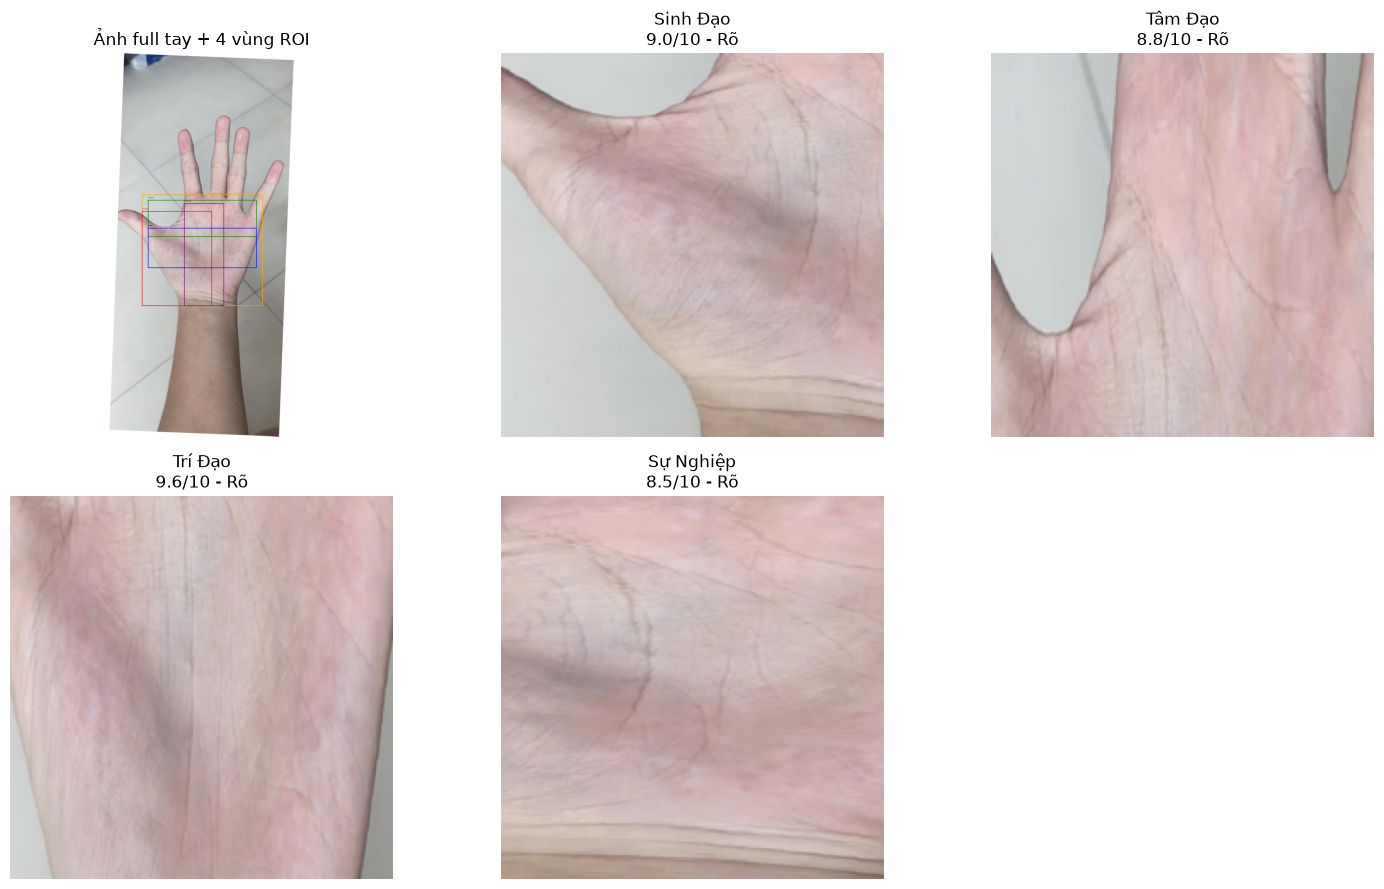

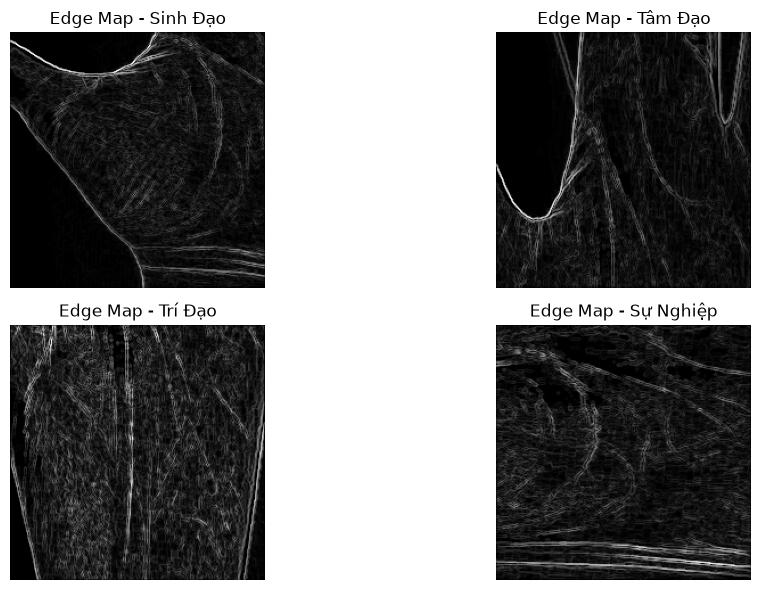

KẾT QUẢ PHÂN TÍCH PALMISTRY AI

Sinh Đạo: 9.0/10 - Rõ (Ảnh: 7.7, AI: 10.0, Conf: 100.0%)
Tâm Đạo: 8.8/10 - Rõ (Ảnh: 7.5, AI: 9.9, Conf: 99.4%)
Trí Đạo: 9.6/10 - Rõ (Ảnh: 9.1, AI: 10.0, Conf: 100.0%)
Sự Nghiệp: 8.5/10 - Rõ (Ảnh: 8.6, AI: 8.4, Conf: 88.7%)

Sức khỏe : 9.1/10
Tình cảm : 8.9/10
Tư duy   : 9.6/10
Sự nghiệp: 8.8/10

TÓM TẮT NHẬN XÉT

Sức khỏe : Sức khỏe nhìn chung khá tốt, thể hiện mức năng lượng ổn định và khả năng hồi phục tốt.
Tình cảm : Tình cảm khá thuận lợi, dễ tạo thiện cảm và có xu hướng sống tình cảm, biết quan tâm người khác.
Tư duy   : Tư duy khá tốt, thể hiện khả năng suy nghĩ rõ ràng, tập trung và xử lý vấn đề tương đối nhanh.
Sự nghiệp: Sự nghiệp có tín hiệu tốt, thể hiện định hướng rõ và khả năng theo đuổi mục tiêu khá mạnh.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def predict_4_roi(crops):
    batch = []

    for ten_vung in THU_TU_VUNG:
        img = crops[ten_vung].convert("RGB").resize(IMG_SIZE)
        arr = np.array(img)
        batch.append(arr)

    batch = np.array(batch)
    batch = preprocess_input(batch)

    preds = model_test.predict(batch, verbose=0)

    return preds

def nhan_xet_suc_khoe(diem):
    if diem >= 8:
        return "Sức khỏe nhìn chung khá tốt, thể hiện mức năng lượng ổn định và khả năng hồi phục tốt."
    elif diem >= 6.3:
        return "Sức khỏe ở mức khá, nhìn chung ổn nhưng vẫn nên chú ý nghỉ ngơi và giữ nhịp sinh hoạt đều."
    elif diem >= 4.5:
        return "Sức khỏe ở mức trung bình, dễ bị ảnh hưởng khi căng thẳng, thiếu ngủ hoặc làm việc quá sức."
    else:
        return "Sức khỏe chưa thật sự nổi bật, nên chú ý hơn đến việc nghỉ ngơi, ăn uống và cân bằng thể lực."


def nhan_xet_tinh_cam(diem):
    if diem >= 8:
        return "Tình cảm khá thuận lợi, dễ tạo thiện cảm và có xu hướng sống tình cảm, biết quan tâm người khác."
    elif diem >= 6.3:
        return "Tình cảm ở mức khá ổn, cảm xúc tương đối cân bằng và biết suy nghĩ cho các mối quan hệ."
    elif diem >= 4.5:
        return "Tình cảm ở mức trung bình, đôi lúc còn khó bộc lộ cảm xúc hoặc dễ suy nghĩ nhiều."
    else:
        return "Tình cảm chưa thật sự rõ nét, có thể cần thêm thời gian để mở lòng và ổn định cảm xúc."


def nhan_xet_tri_dao(diem):
    if diem >= 8:
        return "Tư duy khá tốt, thể hiện khả năng suy nghĩ rõ ràng, tập trung và xử lý vấn đề tương đối nhanh."
    elif diem >= 6.3:
        return "Tư duy ở mức khá, có khả năng phân tích và học hỏi ổn nếu duy trì sự tập trung."
    elif diem >= 4.5:
        return "Tư duy ở mức trung bình, đôi lúc dễ phân tán hoặc cần thêm thời gian để đưa ra quyết định."
    else:
        return "Tư duy chưa thật sự nổi bật, nên rèn thêm khả năng tập trung, ghi nhớ và phân tích vấn đề."


def nhan_xet_su_nghiep(diem):
    if diem >= 8:
        return "Sự nghiệp có tín hiệu tốt, thể hiện định hướng rõ và khả năng theo đuổi mục tiêu khá mạnh."
    elif diem >= 6.3:
        return "Sự nghiệp ở mức khá, có tiềm năng phát triển nếu duy trì sự kiên trì và tập trung."
    elif diem >= 4.5:
        return "Sự nghiệp ở mức trung bình, định hướng có thể còn thay đổi và cần thêm thời gian để ổn định."
    else:
        return "Sự nghiệp chưa thật sự rõ nét, nên tập trung xây dựng mục tiêu và kỹ năng nền tảng trước."


def demo_full_hand_palm_ai(crops):
    preds = predict_4_roi(crops)

    scores = {}
    image_scores = {}
    ai_scores = {}
    ai_conf = {}
    ai_certainty = {}
    edge_maps = {}

    for i, ten_vung in enumerate(THU_TU_VUNG):
        crop_img = crops[ten_vung]
        pred = preds[i]

        ket_qua = tinh_diem_roi(crop_img, pred)

        scores[ten_vung] = ket_qua["score"]
        image_scores[ten_vung] = ket_qua["image_score"]
        ai_scores[ten_vung] = ket_qua["ai_score"]

        ai_conf[ten_vung] = ket_qua["ai_result"]["top_confidence"]
        ai_certainty[ten_vung] = ket_qua["ai_result"]["certainty"]

        edge_maps[ten_vung] = tao_edge_numpy(crop_img)

    tong = tinh_diem_tong(scores)

    plt.figure(figsize=(15, 9))

    plt.subplot(2, 3, 1)
    plt.imshow(anh_minh_hoa)
    plt.axis("off")
    plt.title("Ảnh full tay + 4 vùng ROI")

    for i, ten_vung in enumerate(THU_TU_VUNG):
        plt.subplot(2, 3, i + 2)
        plt.imshow(crops[ten_vung])
        plt.axis("off")
        plt.title(
            f"{TEN_HIEN_THI[ten_vung]}\n"
            f"{scores[ten_vung]:.1f}/10 - {muc_do(scores[ten_vung])}"
        )

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))

    for i, ten_vung in enumerate(THU_TU_VUNG):
        plt.subplot(2, 2, i + 1)
        plt.imshow(edge_maps[ten_vung], cmap="gray")
        plt.axis("off")
        plt.title(f"Edge Map - {TEN_HIEN_THI[ten_vung]}")

    plt.tight_layout()
    plt.show()

    print("KẾT QUẢ PHÂN TÍCH PALMISTRY AI\n")

    for ten_vung in THU_TU_VUNG:
        print(
            f"{TEN_HIEN_THI[ten_vung]}: "
            f"{scores[ten_vung]:.1f}/10 - {muc_do(scores[ten_vung])} "
            f"(Ảnh: {image_scores[ten_vung]:.1f}, AI: {ai_scores[ten_vung]:.1f}, "
            f"Conf: {ai_conf[ten_vung]:.1f}%)"
        )

    print()
    print(f"Sức khỏe : {tong['Sức khỏe']:.1f}/10")
    print(f"Tình cảm : {tong['Tình cảm']:.1f}/10")
    print(f"Tư duy   : {scores['Tri_Dao']:.1f}/10")
    print(f"Sự nghiệp: {tong['Sự nghiệp']:.1f}/10")

    print()
    print("TÓM TẮT NHẬN XÉT\n")
    print("Sức khỏe :", nhan_xet_suc_khoe(tong["Sức khỏe"]))
    print("Tình cảm :", nhan_xet_tinh_cam(tong["Tình cảm"]))
    print("Tư duy   :", nhan_xet_tri_dao(scores["Tri_Dao"]))
    print("Sự nghiệp:", nhan_xet_su_nghiep(tong["Sự nghiệp"]))


if "crops" not in globals() or crops is None:
    print("❌ Chưa có crops. Hãy chạy CELL 12 trước.")

elif "model_test" not in globals() or model_test is None:
    print("❌ Chưa load model. Hãy chạy CELL 13 trước.")

else:
    demo_full_hand_palm_ai(crops)